# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (RGB, resize to 100×100, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Trial 1 settings:** Image = 100×100, Color = RGB, Conv Filters = 32-64-64, Kernel = 3×3, Dense = 64, Dropout = 0.2, Learning Rate = 0.001, Batch = 32, Epochs = 30, Validation = 20%.


## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [3]:
# %pip install numpy
# %pip install matplotlib
# %pip install opencv-python
# %pip install scikit-learn

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [8]:
#from google.colab import drive
#drive.mount('/content/drive')

import os

print(os.getcwd())
data_path = r"\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning"

C:\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning


## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [10]:
import zipfile
import os

# Path to the zip file in Google Drive
# Updated path assuming PetImages.zip is inside 'Colab Notebooks' folder
zip_file_path = r'\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages.zip'

# Destination directory to unzip the files
destination_dir = r'\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location
DATADIR = os.path.join(destination_dir, 'PetImages')
print(f"DATADIR set to: {DATADIR}")

Unzipped '\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages.zip' to '\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages'
DATADIR set to: \Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages\PetImages


Once you confirm the correct path, please update the `zip_file_path` variable in the previous cell (`b8630266`) and re-run it.

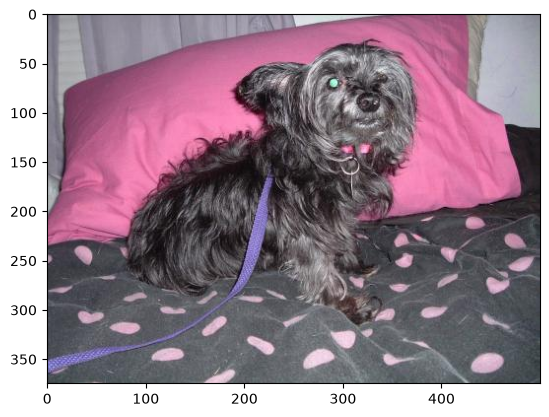

In [12]:
DATADIR = r"\Users\Acer\Doctoral\Bioinformatics\CNN Act Manual Tuning\PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

# ===== TRIAL 2: COLOR = RGB =====
COLOR_MODE = "rgb"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # OpenCV loads color images as BGR; convert to RGB for the CNN.
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        plt.imshow(img_array)
        plt.show()
        break
    break


## Image Inspection

In [14]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[[117 115 126]
  [117 115 126]
  [119 117 130]
  ...
  [132 132 142]
  [131 131 141]
  [131 131 141]]

 [[118 116 127]
  [117 115 126]
  [119 117 130]
  ...
  [134 134 144]
  [133 133 143]
  [133 133 143]]

 [[119 117 128]
  [118 116 127]
  [120 118 131]
  ...
  [136 136 146]
  [135 135 145]
  [135 135 145]]

 ...

 [[ 75  80  84]
  [ 70  75  79]
  [ 69  74  78]
  ...
  [ 74  82  85]
  [ 70  78  81]
  [ 67  75  78]]

 [[ 74  79  83]
  [ 68  73  77]
  [ 65  70  74]
  ...
  [ 66  74  77]
  [ 67  75  78]
  [ 68  76  79]]

 [[ 70  75  79]
  [ 67  72  76]
  [ 66  71  75]
  ...
  [ 69  77  80]
  [ 67  75  78]
  [ 65  73  76]]]
(375, 500, 3)


## Image Resizing

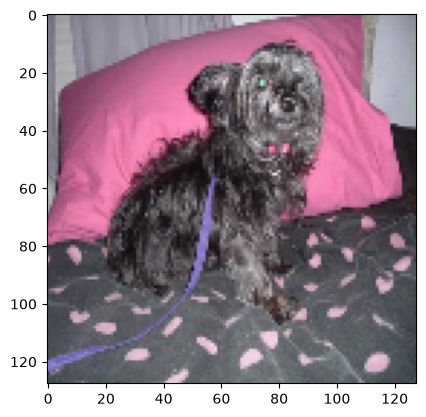

In [16]:
# ===== TRIAL 1: IMAGE SIZE = 128 x 128 =====
IMG_SIZE = 128

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array)
plt.show()


## Assigning Training Data

In [18]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                # ===== TRIAL 2: COLOR = RGB =====
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

                # ===== TRIAL 2: IMAGE SIZE = 128 x 128 =====
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()


## Checking the Number of Training Data

In [20]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [22]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

0
1
0
0
1
0
0
1
0
1


## Assigning Variables for Features and Labels

In [24]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

# ===== TRIAL 2: RGB = 3 CHANNELS =====
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3)
y = np.array(y)  # Keras expects the labels as an array too


## Using the Pickle Module

In [26]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [28]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[187, 189,  68],
        [184, 199,  65],
        [179, 201,  58],
        ...,
        [114,  78,  42],
        [116,  79,  43],
        [122,  82,  47]],

       [[180, 182,  51],
        [181, 190,  51],
        [178, 193,  48],
        ...,
        [110,  75,  40],
        [120,  83,  47],
        [127,  90,  55]],

       [[182, 183,  51],
        [182, 185,  49],
        [181, 185,  48],
        ...,
        [118,  84,  50],
        [126,  92,  57],
        [125,  91,  56]],

       ...,

       [[131, 133,  71],
        [119, 117,  66],
        [106,  97,  62],
        ...,
        [133, 113,  88],
        [134, 115,  89],
        [136, 116,  91]],

       [[134, 136,  72],
        [127, 125,  73],
        [120, 111,  74],
        ...,
        [121, 101,  76],
        [118,  98,  73],
        [122, 102,  76]],

       [[140, 143,  77],
        [138, 136,  81],
        [124, 116,  76],
        ...,
        [104,  84,  59],
        [102,  82,  57],
        [106,  86,  61]]

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

### Trial 1 parameters
- Image: 128×128 RGB
- Convolution filters: 32 → 64 → 64
- Kernel: 3×3
- Dense: 64 neurons
- Dropout: 0.2
- Learning rate: 0.001
- Batch size: 32
- Epochs: 30
- Validation split: 20%


In [33]:
# ============================================================
# TRIAL 2 - CNN MODEL
# ============================================================

#X = X / 255.0

# ============================================================
# ===== CHANGE THESE PARAMETERS FOR FUTURE TRIALS =====
# ============================================================

# ===== IMAGE PARAMETERS =====
IMG_HEIGHT = 128       # CHANGE HERE: Image height
IMG_WIDTH = 128        # CHANGE HERE: Image width
COLOR_CHANNELS = 3     # CHANGE HERE: RGB = 3, Grayscale = 1

# ===== CONVOLUTION FILTERS =====
FILTERS_1 = 32         # CHANGE HERE: First Conv2D filters
FILTERS_2 = 64         # CHANGE HERE: Second Conv2D filters
FILTERS_3 = 64         # CHANGE HERE: Third Conv2D filters

# ===== KERNEL =====
KERNEL_SIZE = (3, 3)   # CHANGE HERE: Kernel size

# ===== DENSE LAYER =====
DENSE_UNITS = 64       # CHANGE HERE: Dense neurons

# ===== DROPOUT =====
DROPOUT_RATE = 0.2     # CHANGE HERE: Dropout rate

# ===== LEARNING RATE =====
LEARNING_RATE = 0.001  # CHANGE HERE: Learning rate

# ===== TRAINING PARAMETERS =====
BATCH_SIZE = 32        # CHANGE HERE: Batch size
EPOCHS = 30            # CHANGE HERE: Number of epochs
VALIDATION_SPLIT = 0.20  # CHANGE HERE: Validation percentage

# ============================================================
# CNN ARCHITECTURE
# ============================================================

model = Sequential()
model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, COLOR_CHANNELS)))

# ===== CONVOLUTION LAYER 1: 32 FILTERS =====
model.add(Conv2D(FILTERS_1, KERNEL_SIZE))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# ===== CONVOLUTION LAYER 2: 64 FILTERS =====
model.add(Conv2D(FILTERS_2, KERNEL_SIZE))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# ===== CONVOLUTION LAYER 3: 64 FILTERS =====
model.add(Conv2D(FILTERS_3, KERNEL_SIZE))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

# ===== DENSE LAYER: 64 NEURONS =====
model.add(Dense(DENSE_UNITS))
model.add(Activation("relu"))

# ===== DROPOUT: 0.2 =====
model.add(Dropout(DROPOUT_RATE))

# ===== OUTPUT LAYER =====
# Binary classification: Dog = 0, Cat = 1
model.add(Dense(1))
model.add(Activation("sigmoid"))

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

print("X dtype:", X.dtype)
print("X shape:", X.shape)
print(f"Approximate X memory: {X.nbytes / (1024**3):.2f} GB")
print("Normalization is performed by the model's Rescaling layer.")

X dtype: uint8
X shape: (24997, 128, 128, 3)
Approximate X memory: 1.14 GB
Normalization is performed by the model's Rescaling layer.


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,265 (3.28 MB)

 Trainable params: 859,265 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# TRIAL 1 - TRAINING
# ============================================================

history = model.fit(
    X,
    y,
    # ===== CHANGE HERE: BATCH SIZE =====
    batch_size=BATCH_SIZE,
    # ===== CHANGE HERE: EPOCHS =====
    epochs=EPOCHS,
    # ===== CHANGE HERE: VALIDATION = 20% =====
    validation_split=VALIDATION_SPLIT
)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 151ms/step - accuracy: 0.5556 - loss: 1.4749 - val_accuracy: 0.5910 - val_loss: 0.6700
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.6155 - loss: 0.6564 - val_accuracy: 0.6384 - val_loss: 0.6375
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.6098 - loss: 0.6585 - val_accuracy: 0.6106 - val_loss: 0.6593
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.6435 - loss: 0.6289 - val_accuracy: 0.6250 - val_loss: 0.6492
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.6479 - loss: 0.6173 - val_accuracy: 0.5042 - val_loss: 0.6931
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.4991 - loss: 0.6938 - val_accuracy: 0.5042 - val_loss: 0.6930
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.5313 - loss: 0.6764 - val_accuracy: 0.5932 - val_loss: 0.6839
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.6763 - loss: 0

In [36]:
# ============================================================
# CNN PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. TRAINING AND VALIDATION ACCURACY
# ------------------------------------------------------------

# Get the accuracy from the last training epoch
training_accuracy = history.history['accuracy'][-1]
validation_accuracy = history.history['val_accuracy'][-1]

# ------------------------------------------------------------
# 2. TRAINING AND VALIDATION LOSS
# ------------------------------------------------------------

training_loss = history.history['loss'][-1]
validation_loss = history.history['val_loss'][-1]

# ------------------------------------------------------------
# 3. TEST DATA
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 4. TEST LOSS AND TEST ACCURACY
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# ------------------------------------------------------------
# 5. PREDICTIONS
# ------------------------------------------------------------

y_pred_probability = model.predict(X_test, verbose=0)

# Convert probabilities to class labels
# 0 = Dog
# 1 = Cat
y_pred = (y_pred_probability > 0.5).astype(int).flatten()

y_test_labels = np.array(y_test).flatten()

# ------------------------------------------------------------
# 6. PRECISION, RECALL, AND F1-SCORE
#    MACRO AVERAGE
# ------------------------------------------------------------

precision_macro = precision_score(
    y_test_labels,
    y_pred,
    average='macro',
    zero_division=0
)

recall_macro = recall_score(
    y_test_labels,
    y_pred,
    average='macro',
    zero_division=0
)

f1_macro = f1_score(
    y_test_labels,
    y_pred,
    average='macro',
    zero_division=0
)

# ------------------------------------------------------------
# 7. DISPLAY ALL RESULTS
# ------------------------------------------------------------

print("=" * 55)
print("                 CNN RESULTS")
print("=" * 55)

print(f"Training Accuracy    : {training_accuracy:.4f} ({training_accuracy * 100:.2f}%)")
print(f"Validation Accuracy  : {validation_accuracy:.4f} ({validation_accuracy * 100:.2f}%)")

print("-" * 55)

print(f"Test Accuracy        : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Test Loss            : {test_loss:.4f}")

print("-" * 55)

print(f"Precision (Macro Avg): {precision_macro:.4f}")
print(f"Recall (Macro Avg)   : {recall_macro:.4f}")
print(f"F1-Score (Macro Avg) : {f1_macro:.4f}")

print("=" * 55)

                 CNN RESULTS
Training Accuracy    : 0.9709 (97.09%)
Validation Accuracy  : 0.7658 (76.58%)
-------------------------------------------------------
Test Accuracy        : 0.9476 (94.76%)
Test Loss            : 0.2879
-------------------------------------------------------
Precision (Macro Avg): 0.9476
Recall (Macro Avg)   : 0.9476
F1-Score (Macro Avg) : 0.9476


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,577,797 (9.83 MB)

 Trainable params: 859,265 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,718,532 (6.56 MB)

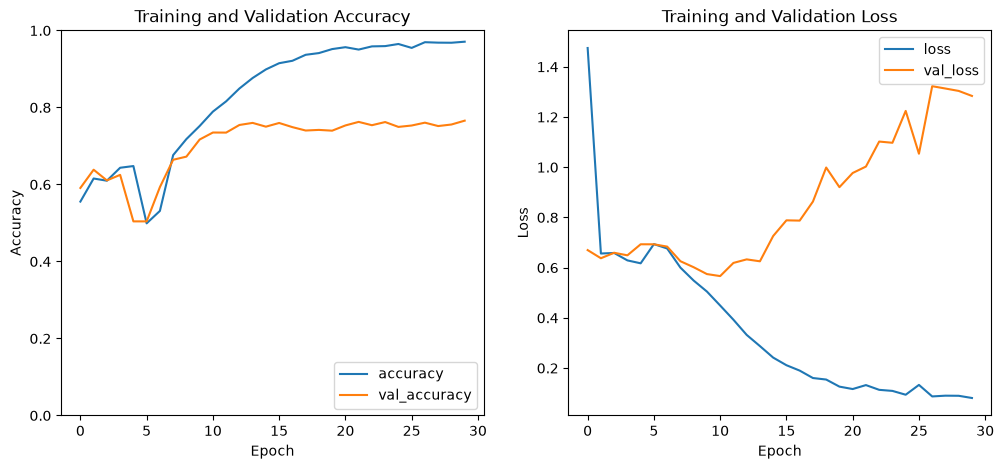

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step

Confusion Matrix:
[[11860   639]
 [  619 11879]]


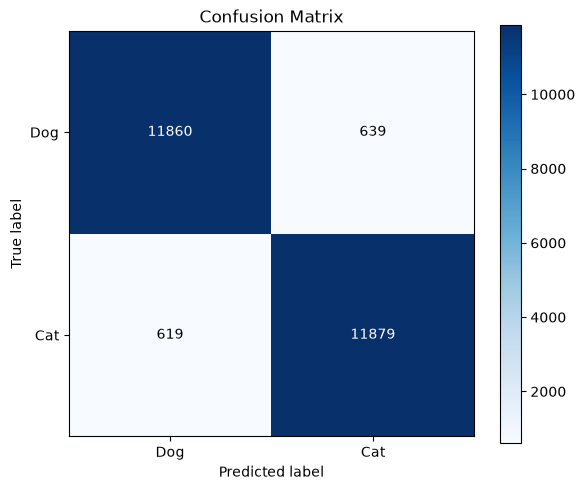

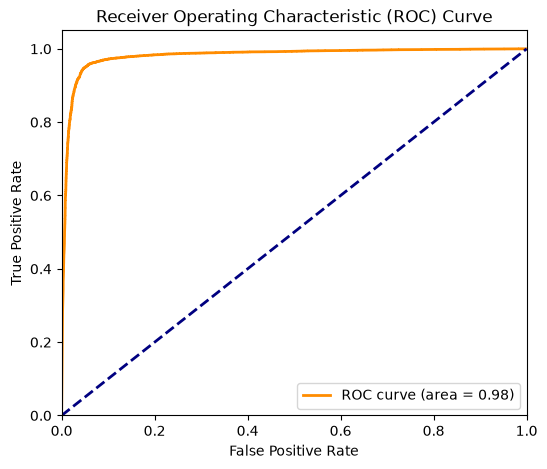

In [37]:
model.summary()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np # numpy is already imported as np earlier

# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# Get predictions for confusion matrix and ROC
y_pred_proba = model.predict(X).ravel() # .ravel() to flatten to 1D array
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
CATEGORIES = ["Dog", "Cat"]
plt.xticks(tick_marks, CATEGORIES)
plt.yticks(tick_marks, CATEGORIES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
fmt = 'd'
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [38]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras' # .keras is the recommended extension for Keras models

# Save the model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later (you can do this in a new session or script)
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(X)
print("\nExample predictions from loaded model:")
print(loaded_model_predictions[:5])


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step

Example predictions from loaded model:
[[2.15709326e-03]
 [1.00000000e+00]
 [1.42392915e-08]
 [1.80511375e-08]
 [9.88353908e-01]]


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predictions for the test samples:
Sample 1: Predicted Class = Dog (Probability: 0.22%) 
Sample 2: Predicted Class = Cat (Probability: 100.00%) 
Sample 3: Predicted Class = Dog (Probability: 0.00%) 
Sample 4: Predicted Class = Dog (Probability: 0.00%) 
Sample 5: Predicted Class = Cat (Probability: 98.84%) 


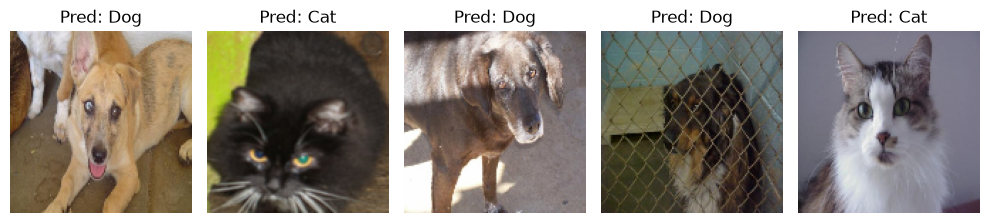

In [40]:
# Select a small subset of data for inference (e.g., the first 5 samples)
# In a real scenario, this would be entirely new, unseen test data.
test_samples = X[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples)

print("Predictions for the test samples:")
for i, prediction in enumerate(inference_predictions):
    # Assuming binary classification with sigmoid output, values close to 1 are 'Cat', close to 0 are 'Dog'
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Probability: {probability:.2f}%) ")

# Optionally, display the images and their predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    
    plt.imshow(test_samples[i])
    
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()